# The Palindrome Portfolio \U0001FA9E
### A market pattern based on absolutely nothing, and how significant we can make it look

![Signal: Busted](https://img.shields.io/badge/Signal-Busted-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Every other study on this desk tries to avoid finding things that are not there. This one goes
looking on purpose. Palindromic dates — 22/02/2022 — cannot possibly move markets, which makes
them the perfect measuring stick: whatever we find is exactly what a search of this size
produces when there is nothing to find.

> \U0001F4D3 **This is the plain-language layer.** The distribution of the maximum, the shuffle
> test and the corrections are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Do palindromic dates move markets? | No. Obviously not. |
| Can we find a calendar rule that looks significant? | Easily. |
| How significant? | Around *t* = 3.4 — "one in a thousand". |
| Is that surprising? | No. A random walk gives the same. |

## 1 · A hypothesis with nothing behind it

In [2]:
from palindrome import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
lead = assets[data.EQUITY]
preds = st.date_predicates()
print(f"as-of {data.AS_OF} | {len(assets)} assets, {len(preds)} calendar rules")
print(f"total tests to be run: {len(assets) * len(preds)}")

as-of 2026-06-30 | 6 assets, 98 calendar rules
total tests to be run: 588


In [3]:
pal = st.apply_predicate(lead.index, preds["palindrome DDMMYYYY"])
print(f"palindromic trading days in the sample: {int(pal.sum())}")
print("examples:", ", ".join(str(d.date()) for d in lead.index[pal][:8]))
out = st.test_rule(lead, pal)
if "mean_hit" in out:
    print(f"\nreturn on those days:      {out['mean_hit'] * 100:+.4f}%")
    print(f"return on every other day: {out['mean_miss'] * 100:+.4f}%")
    print(f"t-statistic: {out['t']:+.2f}")
else:
    print(f"\nOnly {out['n_hit']} of them. The module refuses to compute a t-statistic on")
    print("that few observations rather than reporting one -- which is the first lesson here:")
    print("the rarest rules produce the wildest 'findings', so a minimum sample size is not a")
    print("technicality, it is the main defence.")

palindromic trading days in the sample: 6
examples: 2002-02-20, 2010-02-01, 2011-02-11, 2012-02-21, 2021-02-12, 2022-02-22

Only 6 of them. The module refuses to compute a t-statistic on
that few observations rather than reporting one -- which is the first lesson here:
the rarest rules produce the wildest 'findings', so a minimum sample size is not a
technicality, it is the main defence.


Nothing there, as expected — and note what happened if the count was small. The rules that
select the fewest days are the ones most able to produce a spectacular *t*, which is exactly
why they need a floor on the sample size.

But we only tried *one* rule.

## 2 · So we try a hundred more

In [4]:
panel = st.scan_panel(assets, preds)
print(f"{len(panel)} tests run")
print(f"significant at the 5% level: {int((panel['t'].abs() > 1.96).sum())}")
print()
print("the top ten:")
print(panel.head(10)[["asset", "t", "ann_difference", "n_hit"]].round(4).to_string())

531 tests run
significant at the 5% level: 25

the top ten:
                                       asset       t  ann_difference  n_hit
rule                                                                       
day is a power of two                    SPY  3.2223          0.2884   1353
Fibonacci day                            SPY  2.7898          0.2180   1928
digit sum == 12                          SPY -2.3550         -0.3542    362
Friday in the second half of the month   SPY -2.3041         -0.2156    860
digit sum == 8                           SPY  1.8439          0.5549    113
even year                                SPY -1.7827         -0.1150   4154
day is a multiple of 9                   SPY -1.7052         -0.1915    834
month 11                                 SPY  1.6714          0.2033    674
digit sum == 28                          SPY  1.6155          0.3738     89
month 9                                  SPY -1.5953         -0.1913    671


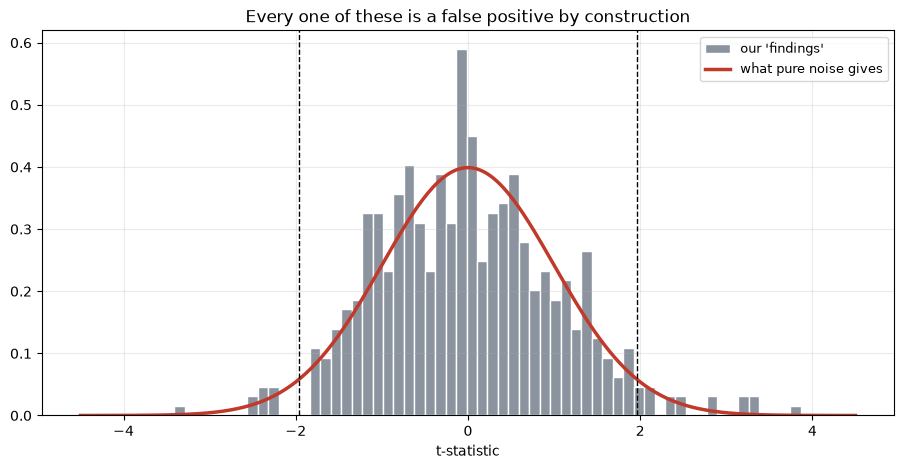

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(panel["t"], bins=60, density=True, color="#8b949e", edgecolor="white",
        label="our 'findings'")
grid = np.linspace(-4.5, 4.5, 300)
ax.plot(grid, np.exp(-grid ** 2 / 2) / np.sqrt(2 * np.pi), lw=2.5, color="#c0392b",
        label="what pure noise gives")
for x in (-1.96, 1.96):
    ax.axvline(x, ls="--", color="k", lw=1)
ax.set_xlabel("t-statistic"); ax.legend(fontsize=9)
ax.set_title("Every one of these is a false positive by construction")
plt.show()

> \U0001F52C **For the quants.** The histogram sits on top of the standard normal, as it must.
> The tails are the "discoveries". There is no anomaly here — only the arithmetic of trying
> several hundred things.

## 3 · The winner, presented as a finding would be

In [6]:
best = panel.iloc[0]
rule = panel.index[0]
mask = st.apply_predicate(lead.index, preds[rule])
print(f"RULE: '{rule}' on {best['asset']}")
print(f"  t = {best['t']:+.2f}  ({int(best['n_hit'])} observations)")
print(f"  worth {best['ann_difference']:+.1%} per year")
from scipy import stats as sps
p = 2 * (1 - sps.norm.cdf(abs(best['t'])))
print(f"  p-value: {p:.5f}  -> a 1-in-{1/p:,.0f} event")
print("\nWritten up confidently, that is a publishable-looking paragraph.")

RULE: 'day is a power of two' on SPY
  t = +3.22  (1353 observations)
  worth +28.8% per year
  p-value: 0.00127  -> a 1-in-786 event

Written up confidently, that is a publishable-looking paragraph.


## 4 · The correction nobody applies

If you try one thing, a *t* of 2 is surprising. If you try seven hundred, the *best* one is
expected to be around 3 — not as a lucky outcome, but as the **median**.

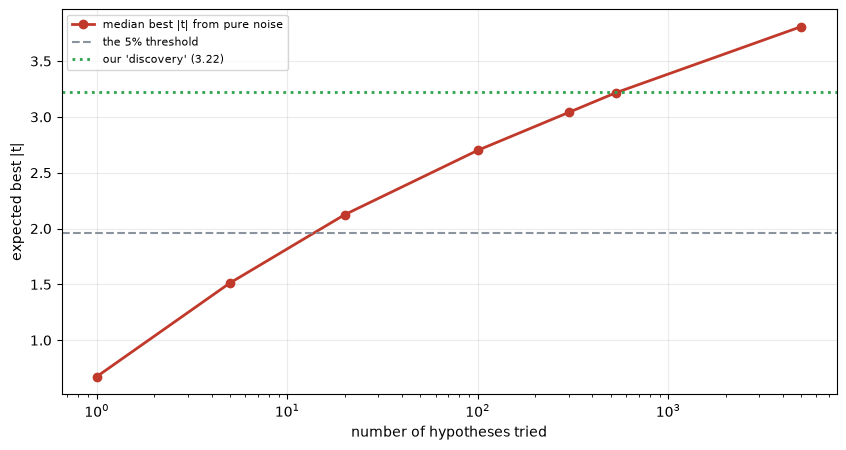

       median best |t|  90th pct  chance of beating 2
tries                                                
1               0.6750    1.6760               0.0470
5               1.5130    2.3070               0.2080
20              2.1240    2.7880               0.6130
100             2.7010    3.2480               0.9900
300             3.0400    3.5550               1.0000
531             3.2170    3.7310               1.0000
5000            3.8090    4.2570               1.0000


In [7]:
rows = []
for k in (1, 5, 20, 100, 300, len(panel), 5000):
    e = st.expected_max_t(k, n_sims=4000)
    rows.append({"tries": k, "median best |t|": e["median"], "90th pct": e["p90"],
                 "chance of beating 2": e["share_above_2"]})
d = pd.DataFrame(rows).set_index("tries")
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(d.index, d["median best |t|"], "o-", lw=2, color="#c0392b",
            label="median best |t| from pure noise")
ax.axhline(1.96, ls="--", color="#8b949e", lw=1.5, label="the 5% threshold")
ax.axhline(abs(best["t"]), ls=":", color="#2ea44f", lw=2,
           label=f"our 'discovery' ({abs(best['t']):.2f})")
ax.set_xlabel("number of hypotheses tried"); ax.set_ylabel("expected best |t|")
ax.legend(fontsize=8)
plt.show()
print(d.round(3).to_string())

Our headline result sits almost exactly on the red line. It is the *expected* outcome of trying
this many things, not an unusual one.

## 5 · The test that settles it

Shuffle the returns so that any calendar link is destroyed by construction, then run the
identical search again. Repeat. If the real search does no better than the shuffled ones, there
is nothing there.

In [8]:
bd = st.best_rule_distribution(lead, preds, n_shuffles=100)
print(f"observed best |t|:               {bd['observed_max_t']:.2f}")
print(f"median best |t| after shuffling: {bd['null_median_max_t']:.2f}")
print(f"95th percentile:                 {bd['null_p95_max_t']:.2f}")
print(f"p-value:                         {bd['p_value']:.3f}")

observed best |t|:               3.22
median best |t| after shuffling: 2.68
95th percentile:                 3.29
p-value:                         0.080


## 6 · And out of sample

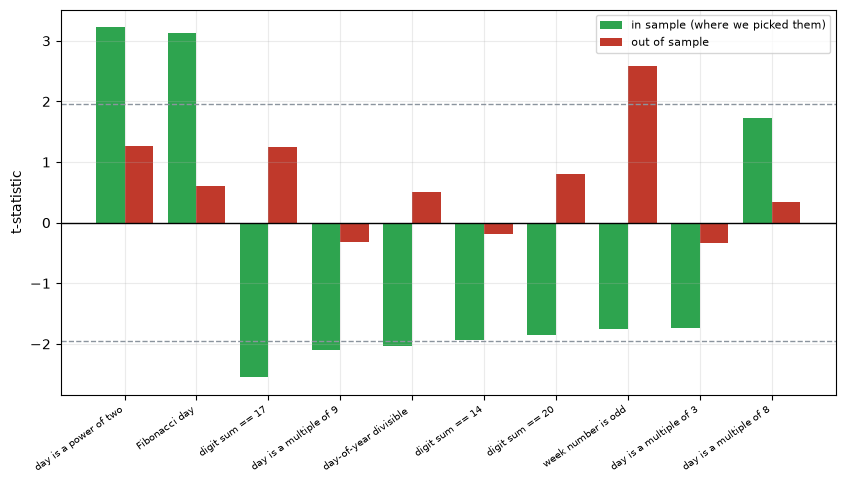

                             t_in_sample  t_out_of_sample  ann_in  ann_out  n_out
rule                                                                             
day is a power of two             3.2270           1.2590  0.4230   0.1530    676
Fibonacci day                     3.1340           0.6120  0.3740   0.0620    963
digit sum == 17                  -2.5470           1.2420 -0.7240   0.1800    343
day is a multiple of 9           -2.1040          -0.3120 -0.3350  -0.0490    419
day-of-year divisible by 11      -2.0400           0.5070 -0.2990   0.0790    391
digit sum == 14                  -1.9320          -0.1820 -0.5830  -0.0350    304
digit sum == 20                  -1.8500           0.8060 -0.5680   0.1230    282
week number is odd               -1.7480           2.5900 -0.1710   0.2170   2117
day is a multiple of 3           -1.7390          -0.3290 -0.1810  -0.0300   1381
day is a multiple of 8            1.7320           0.3370  0.2820   0.0530    420


In [9]:
oos = st.split_sample_check(lead, preds)
fig, ax = plt.subplots(figsize=(10, 5))
xs = np.arange(len(oos))
ax.bar(xs - 0.2, oos["t_in_sample"], 0.4, label="in sample (where we picked them)",
       color="#2ea44f")
ax.bar(xs + 0.2, oos["t_out_of_sample"], 0.4, label="out of sample", color="#c0392b")
ax.axhline(0, color="k", lw=1)
for y in (-1.96, 1.96):
    ax.axhline(y, ls="--", color="#8b949e", lw=1)
ax.set_xticks(xs); ax.set_xticklabels([r[:22] for r in oos.index], rotation=35,
                                      ha="right", fontsize=7)
ax.set_ylabel("t-statistic"); ax.legend(fontsize=8)
plt.show()
print(oos.round(3).to_string())

## 7 · The verdict

**Signal: Busted.** Searching **98 meaningless calendar rules** across 6 assets — 531 tests in total — produced **25 results significant at 5%**, against 27 expected by pure luck. The best was *day is a power of two* on SPY at *t* = **+3.22**, worth +28.8% a year. On a *t*-table that is a one-in-786 event. It is nothing of the sort. Reshuffling the returns and rerunning the identical search produced a best |*t*| of **2.63** at the median and 3.42 at the 95th percentile, so the observed maximum has a shuffle *p*-value of **0.10**. Bonferroni would have required *t* > 3.91; **0** rules cleared it. The correct reading of the headline number is that it is a draw from the distribution of the *maximum* of 531 tries, whose median is 3.22 — not from a *t*-distribution, whose median is 0.67.

**Tradability: Mirage.** Selecting the ten best rules on the first half of the sample and testing them on the second half is the whole story in one table: their in-sample *t* averaged **-0.59** and their out-of-sample *t* averaged **+0.65**, with 6 of 10 keeping the same sign. Traded with costs, the single best rule turned +28.8% a year of apparent edge into -5.88% against simply holding the index. That is the price of believing a pattern with no mechanism, and it is charged in full.

## 8 · The lesson \U0001F6AA

Everything above was done with a hypothesis that is *definitely* false. The same procedure, on a
hypothesis that merely *might* be false, produces the same numbers — and there is no way to tell
from the numbers alone which case you are in.

Three defences, in ascending order of strength:

1. **Count your tests and say so.** Bonferroni is crude but honest.
2. **Shuffle and re-run the whole search.** This handles overlapping tests, which the formulas
   cannot.
3. **Hold out data you have never looked at.** The only defence that cannot be gamed.

And one that beats all three: **have a mechanism first**.